# Análisis de Clustering RFM de Clientes de E-commerce

**Objetivo:**
  * Segmentar clientes en diferentes grupos basados en su comportamiento de compra utilizando el análisis RFM (Recency, Frequency, Monetary) y el algoritmo de clustering K-Means.
  * Enriquecer la clusterización anterior usando otras variables (e.j., categóricas) con otros algoritmos como K-Prototypes.
  * Segmentar clientes en base a la ubicación de su residencia en base al algoritmo DBSCAN.
  * Con esto se busca conocer mejor a los clientes y sus hábitos de compra, de cara a permitir que a la empresa dirigir estrategias de marketing más efectivas a cada segmento.

**Dataset**:
  * La información del dataset se encuentra aquí: https://www.kaggle.com/datasets/bytadit/transactional-ecommerce

### Tabla de Clientes
Contiene la información detallada de los usuarios registrados en la aplicación de comercio electrónico.

- **customer_id** = id único del cliente  
- **first_name** = nombre del cliente  
- **last_name** = apellido del cliente  
- **username** = nombre de usuario del cliente  
- **email** = correo electrónico del cliente  
- **gender** = género del cliente (Masculino (M) o Femenino (F))  
- **device_type** = tipo de dispositivo usado por el cliente al usar la app  
- **device_id** = id del dispositivo usado por el cliente en la app  
- **device_version** = versión detallada del dispositivo usado por el cliente  
- **home_location_lat** = latitud de la ubicación del cliente  
- **home_location_long** = longitud de la ubicación del cliente  
- **home_location** = provincia/región del cliente  
- **home_country** = país del cliente  
- **first_join_date** = fecha de registro inicial del cliente en la app  

---

### Tabla de Productos
Contiene los datos detallados de los productos (moda) vendidos en la aplicación.

- **id** = id del producto  
- **gender** = productos orientados/destinados según género  
- **masterCategory** = categoría principal del producto  
- **subCategory** = subcategoría del producto  
- **articleType** = tipo de producto de moda  
- **baseColour** = color base del producto de moda  
- **season** = productos orientados/destinados según temporada  
- **year** = año de producción  
- **usage** = tipo de uso del producto  
- **productDisplayName** = nombre de visualización del producto en la app  

---

### Tabla de Transacciones
Contiene los datos de cada transacción/pedido realizado por el cliente.  
Cada cliente puede hacer múltiples compras de múltiples productos.

- **created_at** = marca de tiempo en que se creó el dato/transacción  
- **customer_id** = id único de cada cliente  
- **booking_id** = id único de la transacción  
- **session_id** = id de sesión único del usuario al visitar la app  
- **product_metadata** = metadatos del producto comprado  
- **payment_method** = método de pago usado en la transacción  
- **payment_status** = estado del pago (Éxito / Fallido)  
- **promo_amount** = monto del descuento en cada transacción  
- **promo_code** = código promocional  
- **shipment_fee** = coste de envío de la transacción (ongkir)  
- **shipment_date_limit** = fecha límite de envío  
- **shipment_location_lat** = latitud de la ubicación/destino del envío  
- **shipment_location_long** = longitud de la ubicación/destino del envío  
- **total_amount** = monto total a pagar en cada transacción  


### Notas:
- Por simplicidad, no vamos a usar los datos de Click Stream

## 0. Carga de Librerías y Definir funciones comunes

> Dependencias: si `kmodes` no está instalado en el entorno donde se ejecute el notebook, instalarlo con `%pip install kmodes==0.12.2`. En esta entrega se evita ejecutar instalaciones dentro del notebook para que el análisis sea reproducible y no dependa de una descarga en tiempo de corrección.

In [33]:
import ast
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN
from kmodes.kprototypes import KPrototypes

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

### 0.1 Funciones comunes

* Aquí puedes incluir las funciones comunes que uses en el código de cara a reutilizarlas cuando lo necesites.

In [34]:
def find_optimal_k(data, min_k=2, max_k=10, sample_size=10_000, random_state=RANDOM_STATE):
    """Evalúa K-Means con inercia, silueta muestreada y Davies-Bouldin."""
    rows = []
    labels_by_k = {}
    for k in range(min_k, max_k + 1):
        model = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=20,
            algorithm='lloyd',
            random_state=random_state,
        )
        labels = model.fit_predict(data)
        labels_by_k[k] = labels
        sil = silhouette_score(
            data,
            labels,
            sample_size=min(sample_size, len(labels)),
            random_state=random_state,
        )
        db = davies_bouldin_score(data, labels)
        rows.append({'k': k, 'silhouette': sil, 'inertia': model.inertia_, 'davies_bouldin': db})

    scores = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.lineplot(data=scores, x='k', y='silhouette', marker='o', ax=axes[0])
    axes[0].set_title('Silueta por K')
    axes[0].set_ylabel('Silueta')
    sns.lineplot(data=scores, x='k', y='inertia', marker='o', ax=axes[1])
    axes[1].set_title('Método del codo')
    axes[1].set_ylabel('Inercia')
    sns.lineplot(data=scores, x='k', y='davies_bouldin', marker='o', ax=axes[2])
    axes[2].set_title('Davies-Bouldin')
    axes[2].set_ylabel('Menor es mejor')
    plt.tight_layout()
    plt.show()

    return scores, labels_by_k


def parse_product_metadata(metadata_str):
    """Extrae cantidades, importe bruto e identificadores de productos desde la columna product_metadata."""
    try:
        items = ast.literal_eval(metadata_str)
        product_ids = [item.get('product_id') for item in items]
        quantities = [int(item.get('quantity', 0)) for item in items]
        item_prices = [float(item.get('item_price', 0)) for item in items]
        total_quantity = sum(quantities)
        gross_item_amount = sum(q * p for q, p in zip(quantities, item_prices))
        return product_ids, total_quantity, gross_item_amount, len(items)
    except Exception:
        return [], 0, 0.0, 0


def winsorize_series(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)


def profile_clusters(df, cluster_col, cols, agg='median'):
    profile = df.groupby(cluster_col).agg(
        n=('customer_id', 'count'),
        **{c: (c, agg) for c in cols}
    )
    profile['pct_clientes'] = 100 * profile['n'] / len(df)
    return profile.sort_values('n', ascending=False)

In [35]:
def find_optimal_k_kprototypes(data, cat_idx, min_k=2, max_k=6, sample_size=15_000, random_state=RANDOM_STATE):
    """Evalúa K-Prototypes en una muestra reproducible para controlar coste computacional."""
    rng = np.random.default_rng(random_state)
    if len(data) > sample_size:
        sample_idx = rng.choice(len(data), size=sample_size, replace=False)
        data_eval = data[sample_idx]
    else:
        sample_idx = np.arange(len(data))
        data_eval = data

    numeric_idx = [i for i in range(data.shape[1]) if i not in cat_idx]
    numeric_eval = np.asarray(data_eval[:, numeric_idx], dtype=float)

    rows = []
    labels_by_k = {}
    for k in range(min_k, max_k + 1):
        model = KPrototypes(
            n_clusters=k,
            init='Cao',
            n_init=2,
            max_iter=15,
            random_state=random_state,
            verbose=0,
        )
        labels = model.fit_predict(data_eval, categorical=cat_idx)
        labels_by_k[k] = labels
        sil = silhouette_score(
            numeric_eval,
            labels,
            sample_size=min(5_000, len(labels)),
            random_state=random_state,
        )
        rows.append({'k': k, 'cost': model.cost_, 'silhouette_numeric': sil})

    scores = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.lineplot(data=scores, x='k', y='cost', marker='o', ax=axes[0])
    axes[0].set_title('Coste K-Prototypes')
    sns.lineplot(data=scores, x='k', y='silhouette_numeric', marker='o', ax=axes[1])
    axes[1].set_title('Silueta sobre variables numéricas')
    plt.tight_layout()
    plt.show()
    return scores, labels_by_k, sample_idx

In [36]:
# Función para parsear product_metadata.
# Se conserva aquí para que cualquier ejecución lineal use la versión corregida: item_price se multiplica por quantity.
def parse_product_metadata(metadata_str):
    try:
        items = ast.literal_eval(metadata_str)
        product_ids = [item.get('product_id') for item in items]
        quantities = [int(item.get('quantity', 0)) for item in items]
        item_prices = [float(item.get('item_price', 0)) for item in items]
        total_quantity = sum(quantities)
        gross_item_amount = sum(q * p for q, p in zip(quantities, item_prices))
        return product_ids, total_quantity, gross_item_amount, len(items)
    except Exception:
        return [], 0, 0.0, 0

## 1. Cargar datos

In [37]:
# Cargamos los datos de transacciones, clientes y productos.
# En VS Code/Jupyter, el directorio de trabajo del kernel puede ser la carpeta padre del notebook.
# Por eso se comprueban tanto la carpeta actual como la carpeta "Actividad 1".
REQUIRED_DATA_FILES = ['transactions.csv', 'customer.csv', 'product.csv']
DATA_DIR_CANDIDATES = [
    Path('.'),
    Path('Actividad 1'),
    Path('Actividad1'),
    Path('Actividad1_Datos'),
    Path('Actividad 1') / 'Actividad1_Datos',
    Path('Actividad1') / 'Actividad1_Datos',
]

DATA_DIR = next(
    (path for path in DATA_DIR_CANDIDATES if all((path / filename).exists() for filename in REQUIRED_DATA_FILES)),
    None,
)

if DATA_DIR is None:
    checked = '\n'.join(str(path.resolve()) for path in DATA_DIR_CANDIDATES)
    raise FileNotFoundError(
        'No se encuentran transactions.csv, customer.csv y product.csv. '
        f'Rutas comprobadas:\n{checked}'
    )

transactions = pd.read_csv(DATA_DIR / 'transactions.csv', quoting=1, on_bad_lines='skip')
customers = pd.read_csv(DATA_DIR / 'customer.csv')
products = pd.read_csv(DATA_DIR / 'product.csv', on_bad_lines='skip')

print(f'Directorio actual del kernel: {Path.cwd().resolve()}')
print(f'Directorio de datos usado: {DATA_DIR.resolve()}')
print('Datasets cargados correctamente.')
print(f'Transacciones: {transactions.shape}')
print(f'Clientes: {customers.shape}')
print(f'Productos: {products.shape}')

Directorio actual del kernel: /Users/alvaro/Library/Mobile Documents/com~apple~CloudDocs/UNIR/Máster Inteligencia Artificial + PLU/AANS - Aprendizaje Automático no Supervisado/Actividad 1
Directorio de datos usado: /Users/alvaro/Library/Mobile Documents/com~apple~CloudDocs/UNIR/Máster Inteligencia Artificial + PLU/AANS - Aprendizaje Automático no Supervisado/Actividad 1
Datasets cargados correctamente.
Transacciones: (852584, 14)
Clientes: (100000, 15)
Productos: (44424, 10)


In [38]:
print("================ Transactions ================")
display(transactions.head(2))
print("================ Customers ================")
display(customers.head(2))
print("================ Products ================")
display(products.head(2))

================ Transactions ================


,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29T15:22:01.458193Z,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.23,111.97,199832
1,2018-07-30T12:40:22.365620Z,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.01,107.80,155526


================ Customers ================


,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.04,101.36,Sumatera Barat,Indonesia,2019-07-21
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.21,106.82,Jakarta Raya,Indonesia,2017-07-16


================ Products ================


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,"2,011.00",Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,"2,012.00",Casual,Peter England Men Party Blue Jeans


## 1.1 Análisis previo de calidad y distribución de los datos

Antes de construir variables RFM conviene comprobar si los datos tienen sentido para un caso de e-commerce: tamaños de tablas, claves duplicadas, nulos, rangos temporales, distribuciones de importes y variables categóricas, coordenadas geográficas y correlación entre variables numéricas. Esta revisión también determina qué limpieza mínima aplicar antes del modelado.

In [39]:
# Copias de trabajo para revisar calidad sin alterar los datos originales cargados.
transactions_audit = transactions.copy()
customers_audit = customers.copy()
products_audit = products.copy()

transactions_audit['created_at_dt'] = pd.to_datetime(transactions_audit['created_at'], utc=True, errors='coerce')
transactions_audit['shipment_date_limit_dt'] = pd.to_datetime(transactions_audit['shipment_date_limit'], utc=True, errors='coerce')
customers_audit['first_join_date_dt'] = pd.to_datetime(customers_audit['first_join_date'], errors='coerce')
customers_audit['birthdate_dt'] = pd.to_datetime(customers_audit['birthdate'], errors='coerce')

max_join_date_audit = customers_audit['first_join_date_dt'].max()
customers_audit['age_audit'] = ((max_join_date_audit - customers_audit['birthdate_dt']).dt.days / 365.25).round(1)

quality_summary = pd.DataFrame([
    {
        'tabla': 'transactions',
        'filas': len(transactions_audit),
        'columnas': transactions_audit.shape[1],
        'clave_duplicada': transactions_audit.duplicated('booking_id').sum(),
        'fecha_min': transactions_audit['created_at_dt'].min(),
        'fecha_max': transactions_audit['created_at_dt'].max(),
    },
    {
        'tabla': 'customers',
        'filas': len(customers_audit),
        'columnas': customers_audit.shape[1],
        'clave_duplicada': customers_audit.duplicated('customer_id').sum(),
        'fecha_min': customers_audit['first_join_date_dt'].min(),
        'fecha_max': customers_audit['first_join_date_dt'].max(),
    },
    {
        'tabla': 'products',
        'filas': len(products_audit),
        'columnas': products_audit.shape[1],
        'clave_duplicada': products_audit.duplicated('id').sum(),
        'fecha_min': products_audit['year'].min(),
        'fecha_max': products_audit['year'].max(),
    },
])
display(quality_summary)

missing_summary = []
for name, data in [('transactions', transactions_audit), ('customers', customers_audit), ('products', products_audit)]:
    miss = data.isna().mean().sort_values(ascending=False).head(8)
    missing_summary.append(pd.DataFrame({'tabla': name, 'variable': miss.index, 'pct_nulos': (100 * miss.values).round(2)}))
display(pd.concat(missing_summary, ignore_index=True))

logical_checks = pd.DataFrame({
    'comprobacion': [
        'Transacciones con total_amount negativo',
        'Transacciones exitosas con total_amount <= 0',
        'Coordenadas de envío fuera de rango',
        'Clientes con edad fuera de 12-90 años',
        'Clientes sin coordenadas de residencia',
    ],
    'casos': [
        int((transactions_audit['total_amount'] < 0).sum()),
        int(((transactions_audit['payment_status'] == 'Success') & (transactions_audit['total_amount'] <= 0)).sum()),
        int((~transactions_audit['shipment_location_lat'].between(-90, 90) | ~transactions_audit['shipment_location_long'].between(-180, 180)).sum()),
        int((~customers_audit['age_audit'].between(12, 90)).sum()),
        int(customers_audit[['home_location_lat', 'home_location_long']].isna().any(axis=1).sum()),
    ],
})
display(logical_checks)

,tabla,filas,columnas,clave_duplicada,fecha_min,fecha_max
0,transactions,852584,16,0,2016-06-30 23:18:44.792905+00:00,2022-07-31 23:59:45.821469+00:00
1,customers,100000,18,0,2016-06-30 00:00:00,2022-07-31 00:00:00
2,products,44424,10,0,"2,007.00","2,019.00"


,tabla,variable,pct_nulos
0,transactions,promo_code,61.70
1,transactions,created_at,0.00
2,transactions,customer_id,0.00
3,transactions,booking_id,0.00
4,transactions,session_id,0.00
5,transactions,product_metadata,0.00
6,transactions,payment_method,0.00
7,transactions,payment_status,0.00
8,customers,customer_id,0.00
9,customers,first_name,0.00


,comprobacion,casos
0,Transacciones con total_amount negativo,0
1,Transacciones exitosas con total_amount <= 0,0
2,Coordenadas de envío fuera de rango,0
3,Clientes con edad fuera de 12-90 años,594
4,Clientes sin coordenadas de residencia,0


**Lectura rápida del análisis previo.** Los datos tienen una estructura coherente para un e-commerce: hay 852.584 transacciones, 100.000 clientes y 44.424 productos, sin duplicados en las claves principales (`booking_id`, `customer_id`, `id`). La ventana temporal de transacciones y altas de clientes cubre de 2016 a 2022, por lo que tiene sentido construir métricas de recencia, frecuencia y antigüedad.

En calidad de datos, no aparecen importes negativos, compras exitosas con `total_amount <= 0`, coordenadas fuera de rango ni clientes sin geolocalización. El principal nulo relevante es `promo_code` (~61,7%), pero es esperable porque muchas compras no usan cupón; no debe imputarse como error, sino interpretarse como ausencia de promoción. En productos hay pocos nulos en variables descriptivas (`usage`, `season`, `baseColour`), que no afectan al RFM.

Las distribuciones también son razonables: `total_amount` está muy sesgada a la derecha (mediana cercana a 303k frente a media cercana a 550k y p99 superior a 4,2M), algo típico cuando pocos pedidos concentran mucho valor. `promo_amount` tiene masa en cero y `shipment_fee` toma valores discretos frecuentes, por lo que no conviene asumir normalidad. Esto justifica usar `log1p` y escalado robusto antes de K-Means/K-Prototypes.

Las variables categóricas están desbalanceadas de forma plausible: predominan Android (~76,6%), mujeres (~64,2%) y provincias como Jakarta Raya, Jawa Barat y Jawa Tengah. Por eso estas variables deben tratarse como categóricas nominales y no como números ordinales. La matriz de correlación muestra correlaciones lineales prácticamente nulas entre importe, descuento, envío y coordenadas; por tanto, no hay redundancias fuertes que obliguen a eliminar variables en esta fase. La única limpieza necesaria es conservadora: eliminar duplicados si aparecieran, descartar registros con campos críticos nulos y tratar edades fuera del rango 12-90 mediante imputación/recorte en el modelado posterior.

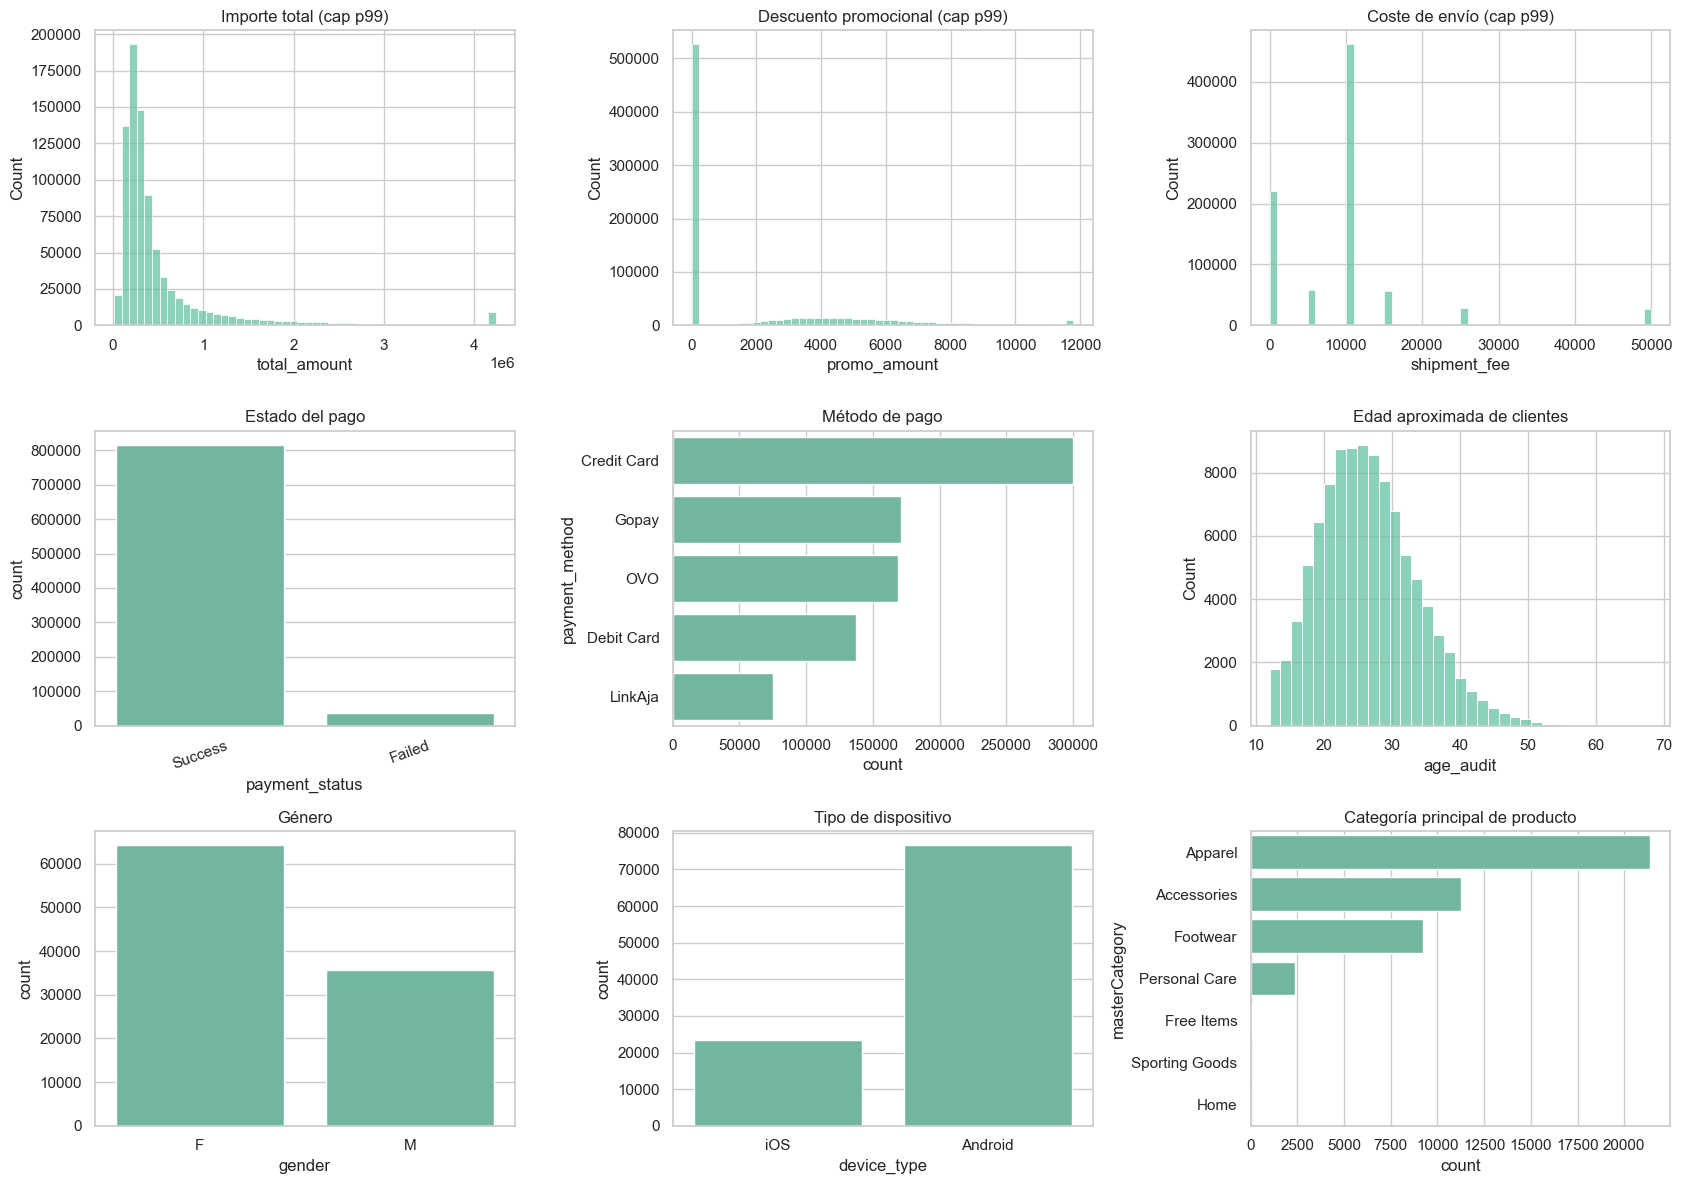

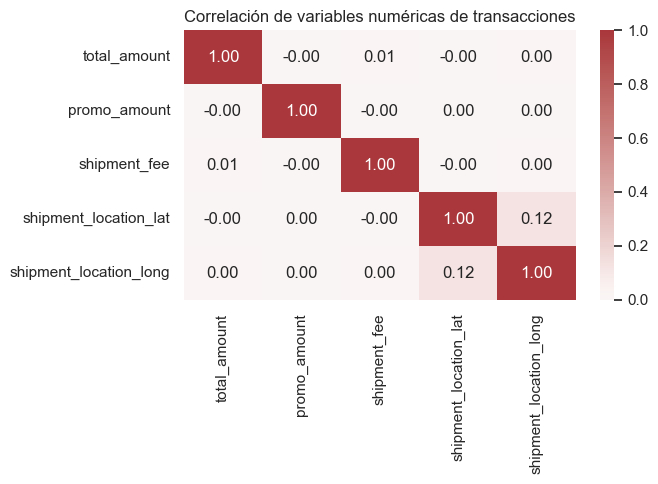

,tabla,filas_originales,filas_limpias,criterio
0,transactions,852584,852584,"Eliminar booking_id duplicado, fechas/ids/impo..."
1,customers,100000,100000,Eliminar customer_id duplicado y registros sin...
2,products,44424,44424,Eliminar id duplicado o nulo; el catálogo se u...


In [40]:
# Distribuciones principales. Se recortan visualmente al percentil 99 para que los outliers no oculten el patrón central.
fig, axes = plt.subplots(3, 3, figsize=(17, 12))

for ax, col, title in zip(
    axes[0],
    ['total_amount', 'promo_amount', 'shipment_fee'],
    ['Importe total', 'Descuento promocional', 'Coste de envío']
):
    x = transactions_audit[col].clip(upper=transactions_audit[col].quantile(.99))
    sns.histplot(x, bins=50, ax=ax)
    ax.set_title(f'{title} (cap p99)')

sns.countplot(data=transactions_audit, x='payment_status', ax=axes[1, 0])
axes[1, 0].set_title('Estado del pago')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.countplot(data=transactions_audit, y='payment_method', order=transactions_audit['payment_method'].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title('Método de pago')

sns.histplot(customers_audit['age_audit'].dropna().clip(12, 90), bins=35, ax=axes[1, 2])
axes[1, 2].set_title('Edad aproximada de clientes')

sns.countplot(data=customers_audit, x='gender', ax=axes[2, 0])
axes[2, 0].set_title('Género')

sns.countplot(data=customers_audit, x='device_type', ax=axes[2, 1])
axes[2, 1].set_title('Tipo de dispositivo')

sns.countplot(data=products_audit, y='masterCategory', order=products_audit['masterCategory'].value_counts().head(10).index, ax=axes[2, 2])
axes[2, 2].set_title('Categoría principal de producto')

plt.tight_layout()
plt.show()

# Correlación entre variables numéricas relevantes antes de construir RFM.
corr_cols = ['total_amount', 'promo_amount', 'shipment_fee', 'shipment_location_lat', 'shipment_location_long']
corr_data = transactions_audit[corr_cols].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlación de variables numéricas de transacciones')
plt.tight_layout()
plt.show()

# Limpieza mínima derivada del análisis de calidad.
transactions_clean = transactions_audit.drop_duplicates('booking_id').copy()
transactions_clean = transactions_clean.dropna(subset=['created_at_dt', 'customer_id', 'payment_status', 'total_amount'])
transactions_clean = transactions_clean[transactions_clean['total_amount'] >= 0].copy()
transactions_clean['created_at'] = transactions_clean['created_at_dt']
transactions_clean['shipment_date_limit'] = transactions_clean['shipment_date_limit_dt']
transactions_clean = transactions_clean.drop(columns=['created_at_dt', 'shipment_date_limit_dt'])

customers_clean = customers_audit.drop_duplicates('customer_id').copy()
customers_clean = customers_clean.dropna(subset=['customer_id', 'first_join_date_dt']).copy()
customers_clean['first_join_date'] = customers_clean['first_join_date_dt']
customers_clean['birthdate'] = customers_clean['birthdate_dt']
customers_clean = customers_clean.drop(columns=['first_join_date_dt', 'birthdate_dt'])

products_clean = products_audit.drop_duplicates('id').copy()
products_clean = products_clean.dropna(subset=['id']).copy()

cleaning_summary = pd.DataFrame({
    'tabla': ['transactions', 'customers', 'products'],
    'filas_originales': [len(transactions), len(customers), len(products)],
    'filas_limpias': [len(transactions_clean), len(customers_clean), len(products_clean)],
    'criterio': [
        'Eliminar booking_id duplicado, fechas/ids/importes críticos nulos e importes negativos; no se eliminan pagos fallidos hasta filtrar RFM.',
        'Eliminar customer_id duplicado y registros sin fecha de alta; se conservan nulos no críticos para imputación posterior.',
        'Eliminar id duplicado o nulo; el catálogo se usa solo como apoyo descriptivo.',
    ],
})
display(cleaning_summary)

## 2. Preprocesamiento y Creación de Features RFM

In [41]:
%%time
# Procesamiento inicial orientado a RFM.
df = globals().get('transactions_clean', transactions).copy()
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')

print(f'Transacciones originales: {len(df):,}')
print(df['payment_status'].value_counts(dropna=False))

# Para RFM usamos únicamente compras exitosas. Las fallidas no representan comportamiento de compra confirmado.
df_success = df[df['payment_status'].eq('Success')].dropna(subset=['created_at', 'customer_id', 'total_amount']).copy()
print(f'Transacciones exitosas usadas en RFM: {len(df_success):,}')

parsed_data = df_success['product_metadata'].apply(lambda x: pd.Series(parse_product_metadata(x)))
df_success['product_ids'] = parsed_data[0]
df_success['total_quantity'] = parsed_data[1]
df_success['gross_item_amount'] = parsed_data[2]
df_success['num_items'] = parsed_data[3]

# Comprobación de coherencia: total_amount suele equivaler a importe de producto + envío - promoción.
df_success['reconstructed_total'] = df_success['gross_item_amount'] + df_success['shipment_fee'] - df_success['promo_amount']
check_cols = ['gross_item_amount', 'shipment_fee', 'promo_amount', 'total_amount', 'reconstructed_total']
display(df_success[check_cols].head())
print('Diferencia absoluta mediana entre total_amount y total reconstruido:',
      np.median(np.abs(df_success['total_amount'] - df_success['reconstructed_total'])))

Transacciones originales: 852,584
payment_status
Success    815964
Failed      36620
Name: count, dtype: int64
Transacciones exitosas usadas en RFM: 815,964


,gross_item_amount,shipment_fee,promo_amount,total_amount,reconstructed_total
0,"191,247.00",10000,1415,199832,"199,832.00"
1,"145,526.00",10000,0,155526,"155,526.00"
2,"540,696.00",10000,0,550696,"550,696.00"
3,"271,012.00",0,0,271012,"271,012.00"
4,"198,753.00",0,0,198753,"198,753.00"


Diferencia absoluta mediana entre total_amount y total reconstruido: 0.0
CPU times: user 42.6 s, sys: 6.82 s, total: 49.4 s
Wall time: 54.5 s


#### PREGUNTA 1:
* ¿Cómo calculamos las variables RFM en base a los datos disponibles?

#### RESPUESTA:

Las variables RFM se calculan a nivel de cliente sobre las transacciones con `payment_status = Success`, ya que una compra fallida no debe contar como frecuencia ni como valor monetario real.

- **Recency (R)**: número de días entre la última compra exitosa del cliente y una fecha de referencia. Uso como referencia el día posterior a la última fecha de compra del dataset para evitar recencias iguales a 0.
- **Frequency (F)**: número de compras exitosas, medido como número de `booking_id` únicos por cliente.
- **Monetary (M)**: suma de `total_amount` de las compras exitosas. Esta variable representa el importe final pagado en checkout e incorpora descuentos (`promo_amount`) y envío (`shipment_fee`). También calculo `gross_item_amount` desde `product_metadata` para verificar la coherencia, pero para RFM uso `total_amount` porque es el valor económico efectivamente transaccionado.

In [42]:
analysis_date = df_success['created_at'].max() + pd.Timedelta(days=1)

rfm = (
    df_success
    .groupby('customer_id')
    .agg(
        recency=('created_at', lambda x: (analysis_date - x.max()).days),
        frequency=('booking_id', 'nunique'),
        monetary=('total_amount', 'sum'),
        gross_item_amount=('gross_item_amount', 'sum'),
        total_quantity=('total_quantity', 'sum'),
        avg_order_value=('total_amount', 'mean'),
        avg_items=('num_items', 'mean'),
        first_purchase=('created_at', 'min'),
        last_purchase=('created_at', 'max'),
    )
    .reset_index()
)
rfm['customer_lifetime_days'] = (rfm['last_purchase'] - rfm['first_purchase']).dt.days.clip(lower=0)

print(f'Fecha de referencia RFM: {analysis_date}')
print(f'Clientes con al menos una compra exitosa: {len(rfm):,}')
display(rfm.head())
display(rfm[['recency', 'frequency', 'monetary', 'avg_order_value', 'total_quantity']].describe(percentiles=[.01, .25, .5, .75, .95, .99]).T)

Fecha de referencia RFM: 2022-08-01 23:59:19.821469+00:00
Clientes con al menos una compra exitosa: 50,242


,customer_id,recency,frequency,monetary,gross_item_amount,total_quantity,avg_order_value,avg_items,first_purchase,last_purchase,customer_lifetime_days
0,3,36,49,20891374,"20,676,434.00",86,"426,354.57",1.41,2018-08-25 18:54:03.844494+00:00,2022-06-26 15:41:52.844494+00:00,1400
1,8,78,7,3898561,"3,861,260.00",19,"556,937.29",1.14,2021-02-13 09:47:39.656991+00:00,2022-05-15 22:46:22.656991+00:00,456
2,9,65,6,2638665,"2,603,665.00",10,"439,777.50",1.33,2021-06-27 01:51:48.421034+00:00,2022-05-28 08:44:32.421034+00:00,335
3,11,147,1,197533,"192,025.00",1,"197,533.00",1.00,2022-03-07 14:29:13.759159+00:00,2022-03-07 14:29:13.759159+00:00,0
4,15,208,5,2134870,"2,101,232.00",9,"426,974.00",1.80,2019-09-30 04:47:36.105040+00:00,2022-01-05 06:07:58.105040+00:00,828


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
recency,"50,242.00",300.60,434.43,1.00,1.00,40.00,112.00,362.00,"1,359.00","1,996.59","2,222.00"
frequency,"50,242.00",16.24,28.66,1.00,1.00,2.00,6.00,17.00,68.00,139.00,550.00
monetary,"50,242.00","8,936,691.30","16,087,604.88","27,450.00","117,157.06","773,443.50","3,010,699.00","9,832,860.75","38,344,838.90","77,238,799.38","320,061,849.00"
avg_order_value,"50,242.00","548,884.59","460,064.43","27,450.00","114,333.94","316,301.94","459,619.49","625,153.97","1,204,565.89","2,341,963.24","13,904,505.00"
total_quantity,"50,242.00",35.28,63.42,1.00,1.00,3.00,12.00,39.00,150.00,299.00,"1,259.00"


#### PREGUNTA 2:
* Realiza un análisis exploratorio de datos de las variables RFM. ¿Es necesario realizar alguna transformación sobre ellas para usarlas en clustering?

#### Respuesta

Sí, es necesario transformar las variables RFM antes de usar clustering. Las tres son asimétricas, especialmente `frequency` y `monetary`, donde pocos clientes concentran muchas compras y gasto. Si se aplicara K-Means directamente, la distancia euclídea quedaría dominada por la escala monetaria y por outliers.

El preprocesamiento elegido es:

- aplicar `log1p` a `recency`, `frequency` y `monetary` para reducir asimetría sin perder ceros potenciales;
- escalar con `RobustScaler`, más estable ante colas largas que una estandarización basada solo en media y desviación típica;
- revisar boxplots e histogramas antes y después de la transformación.

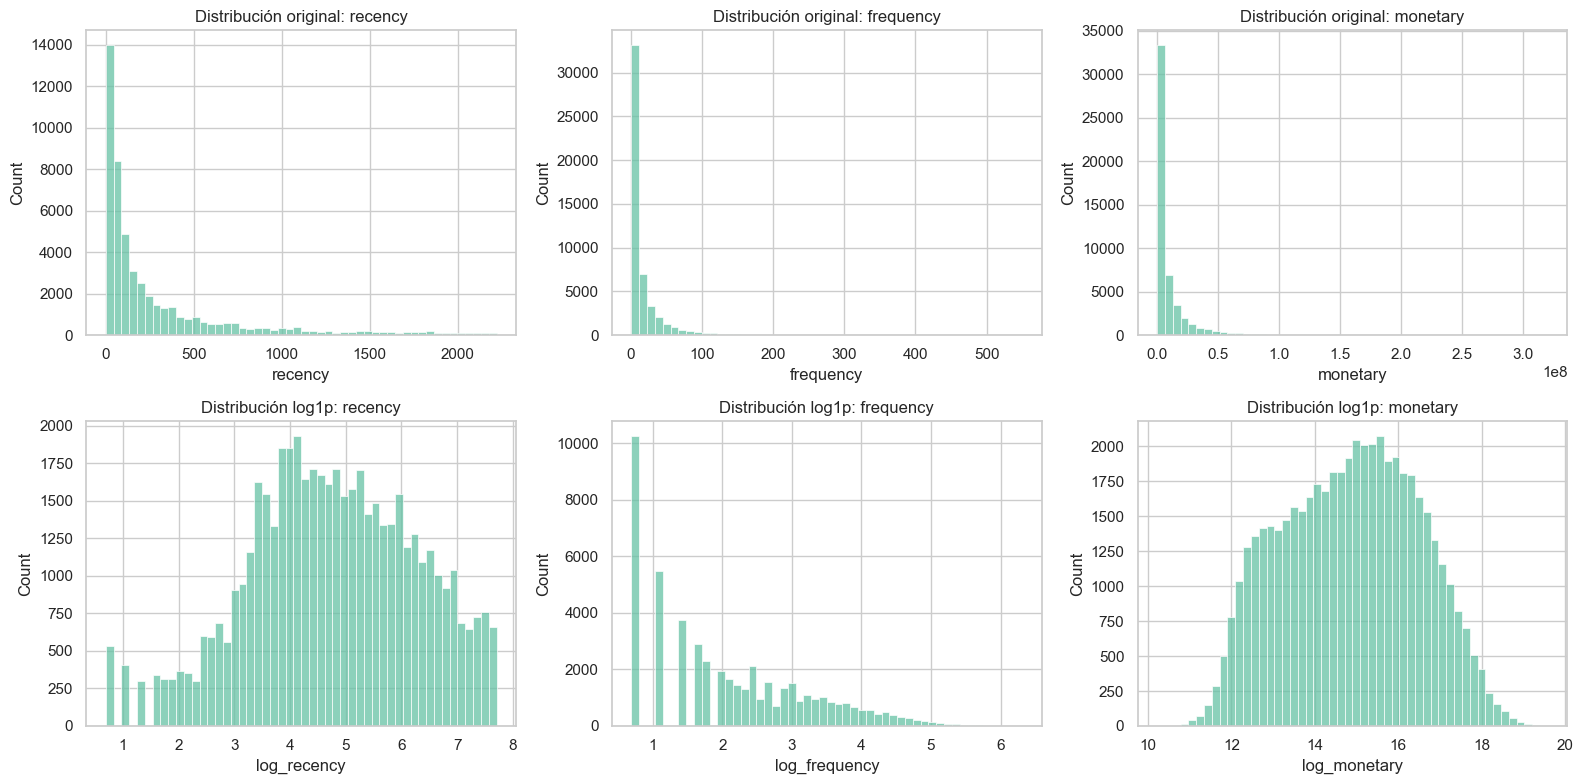

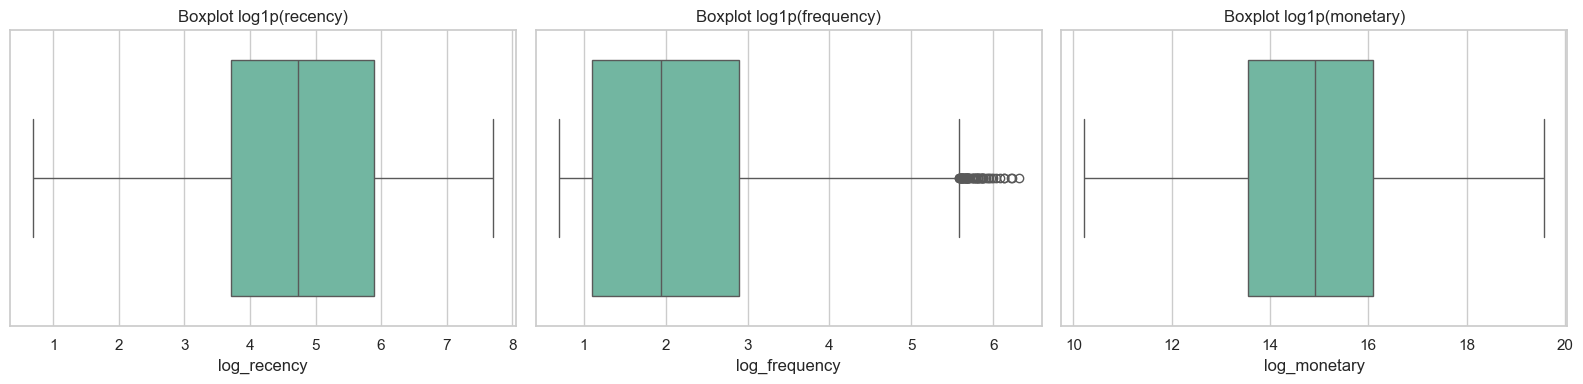

,count,mean,std,min,25%,50%,75%,max
scaled_log_recency,"50,242.00",0.01,0.70,-1.85,-0.46,0.00,0.54,1.37
scaled_log_frequency,"50,242.00",0.08,0.65,-0.70,-0.47,0.00,0.53,2.44
scaled_log_monetary,"50,242.00",-0.03,0.64,-1.85,-0.53,0.00,0.47,1.84


In [43]:
rfm_model = rfm.copy()
rfm_cols = ['recency', 'frequency', 'monetary']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(rfm_cols):
    sns.histplot(rfm_model[col], bins=50, ax=axes[0, i])
    axes[0, i].set_title(f'Distribución original: {col}')
    rfm_model[f'log_{col}'] = np.log1p(rfm_model[col])
    sns.histplot(rfm_model[f'log_{col}'], bins=50, ax=axes[1, i])
    axes[1, i].set_title(f'Distribución log1p: {col}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(rfm_cols):
    sns.boxplot(x=rfm_model[f'log_{col}'], ax=axes[i])
    axes[i].set_title(f'Boxplot log1p({col})')
plt.tight_layout()
plt.show()

rfm_scaler = RobustScaler()
X_rfm = rfm_scaler.fit_transform(rfm_model[[f'log_{c}' for c in rfm_cols]])
X_rfm = pd.DataFrame(X_rfm, columns=[f'scaled_log_{c}' for c in rfm_cols], index=rfm_model.index)
display(X_rfm.describe().T)

## 3. Clustering con K-Means

#### PREGUNTA 3:
* Realiza una clusterización con K-Means sobre los datos de RFM calculados previamente

#### RESPUESTA:

Antes de ejecutar K-Means conviene fijar un rango de K que tenga sentido de negocio. En una segmentación RFM, `K=2` suele separar únicamente clientes activos frente a inactivos, pero no permite diferenciar clientes recurrentes, ocasionales o de alto valor. Por ello evalúo `K=2..8` con silueta, codo y Davies-Bouldin, y selecciono un K que sea técnicamente razonable e interpretable comercialmente.

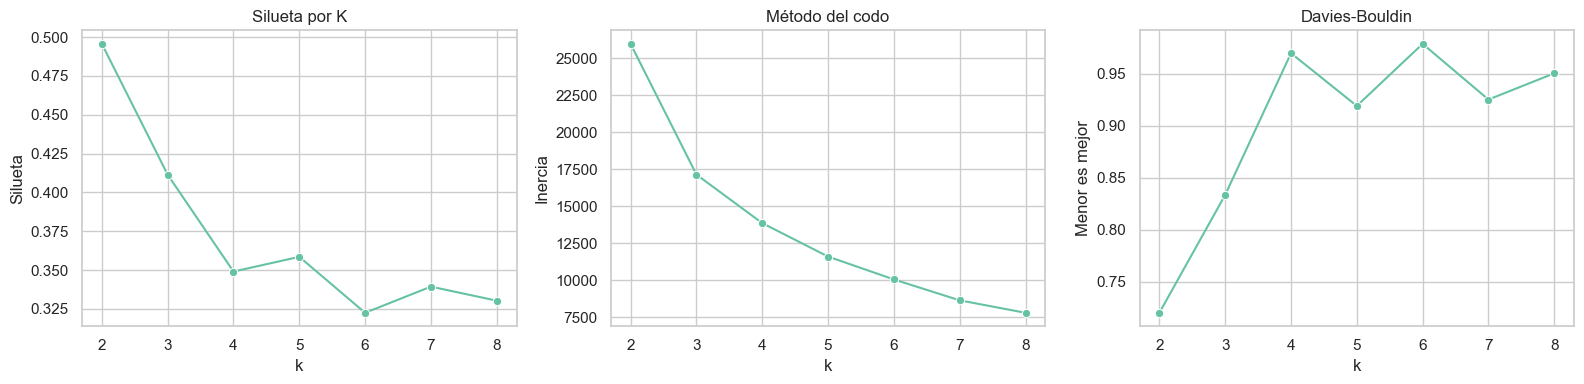

,k,silhouette,inertia,davies_bouldin
0,2,0.50,"25,975.27",0.72
1,3,0.41,"17,144.64",0.83
2,4,0.35,"13,865.35",0.97
3,5,0.36,"11,606.10",0.92
4,6,0.32,"10,061.51",0.98
5,7,0.34,"8,649.25",0.93
6,8,0.33,"7,807.27",0.95


,n,recency,frequency,monetary,avg_order_value,total_quantity,pct_clientes
kmeans_cluster,,,,,,,
3,9345,23.00,45.00,"25,290,345.00","542,454.45",99.00,18.60
1,13896,58.00,12.00,"6,657,754.50","508,192.84",26.00,27.66
0,14103,183.00,4.00,"1,782,845.00","422,775.83",7.00,28.07
2,12898,715.00,1.00,"380,354.50","291,276.50",1.00,25.67


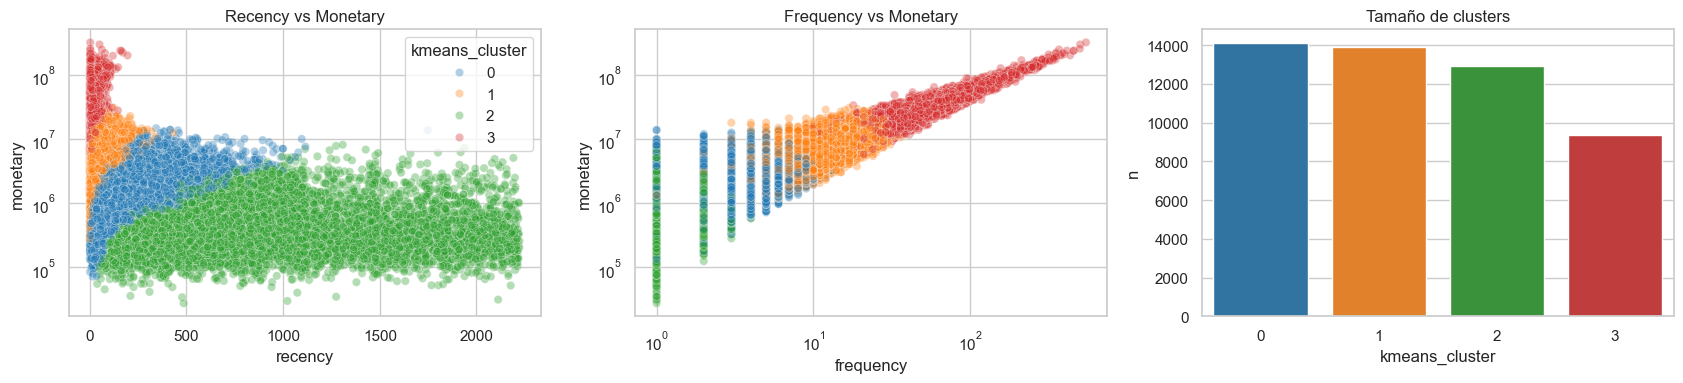

In [44]:
kmeans_scores, _ = find_optimal_k(X_rfm, min_k=2, max_k=8)
display(kmeans_scores)

# La silueta favorece soluciones muy gruesas; se elige K=4 por equilibrio entre separación, codo e interpretabilidad RFM.
KMEANS_K = 4
kmeans = KMeans(n_clusters=KMEANS_K, init='k-means++', n_init=30, random_state=RANDOM_STATE)
rfm_model['kmeans_cluster'] = kmeans.fit_predict(X_rfm)

kmeans_profile = profile_clusters(
    rfm_model,
    'kmeans_cluster',
    ['recency', 'frequency', 'monetary', 'avg_order_value', 'total_quantity'],
)
display(kmeans_profile.sort_values('recency'))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.scatterplot(data=rfm_model, x='recency', y='monetary', hue='kmeans_cluster', alpha=.35, ax=axes[0], palette='tab10')
axes[0].set_yscale('log')
axes[0].set_title('Recency vs Monetary')
sns.scatterplot(data=rfm_model, x='frequency', y='monetary', hue='kmeans_cluster', alpha=.35, ax=axes[1], palette='tab10', legend=False)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Frequency vs Monetary')
sns.barplot(data=kmeans_profile.reset_index(), x='kmeans_cluster', y='n', ax=axes[2], palette='tab10')
axes[2].set_title('Tamaño de clusters')
plt.tight_layout()
plt.show()

#### PREGUNTA 4:
* ¿Qué interpretación haces de los resultados obtenidos con la clusterización? ¿Qué acciones propondrías hacer sobre ellos?

#### RESPUESTA:

La segmentación K-Means sobre RFM produce grupos accionables. Leyendo los centroides/perfiles del notebook, se distinguen cuatro patrones típicos:

- **Clientes recientes, frecuentes y de alto valor**: deben protegerse con programas VIP, preventa, bundles y beneficios de fidelización.
- **Clientes recientes de valor/frecuencia media**: candidatos a campañas de cross-selling y recomendaciones personalizadas para aumentar frecuencia y cesta media.
- **Clientes ocasionales o de bajo gasto**: conviene activar promociones de segunda compra, umbrales de envío gratis o campañas por categoría preferida.
- **Clientes inactivos o monocompra antigua**: requieren reactivación de bajo coste; si no responden, deben excluirse de campañas caras.

No usaría los clusters como segmentos definitivos sin seguimiento temporal: la recomendación práctica es monitorizar migraciones entre clusters y medir uplift de campañas por grupo.

,clientes,recency_mediana,frequency_mediana,monetary_mediana,ticket_medio_mediano
kmeans_segment,,,,,
VIP / champions,9345,23.00,45.00,"25,290,345.00","542,454.45"
Recurrentes de valor medio,13896,58.00,12.00,"6,657,754.50","508,192.84"
Ocasionales recientes,14103,183.00,4.00,"1,782,845.00","422,775.83"
Inactivos o monocompra,12898,715.00,1.00,"380,354.50","291,276.50"


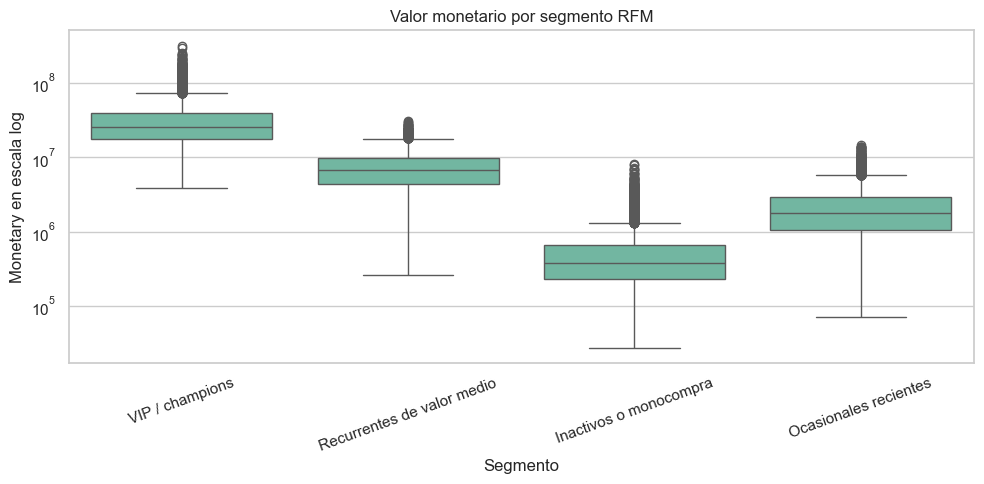

In [45]:
# Etiquetado interpretativo automático según perfil relativo.
profile_for_labels = kmeans_profile.copy()
profile_for_labels['rank_recency'] = profile_for_labels['recency'].rank(ascending=True)
profile_for_labels['rank_frequency'] = profile_for_labels['frequency'].rank(ascending=False)
profile_for_labels['rank_monetary'] = profile_for_labels['monetary'].rank(ascending=False)
profile_for_labels['score'] = profile_for_labels[['rank_recency', 'rank_frequency', 'rank_monetary']].sum(axis=1)

best_cluster = profile_for_labels['score'].idxmin()
worst_cluster = profile_for_labels['score'].idxmax()
labels = {}
for cl in profile_for_labels.index:
    if cl == best_cluster:
        labels[cl] = 'VIP / champions'
    elif cl == worst_cluster:
        labels[cl] = 'Inactivos o monocompra'
    elif profile_for_labels.loc[cl, 'frequency'] >= profile_for_labels['frequency'].median():
        labels[cl] = 'Recurrentes de valor medio'
    else:
        labels[cl] = 'Ocasionales recientes'

rfm_model['kmeans_segment'] = rfm_model['kmeans_cluster'].map(labels)
display(rfm_model.groupby('kmeans_segment').agg(
    clientes=('customer_id', 'count'),
    recency_mediana=('recency', 'median'),
    frequency_mediana=('frequency', 'median'),
    monetary_mediana=('monetary', 'median'),
    ticket_medio_mediano=('avg_order_value', 'median'),
).sort_values('monetary_mediana', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=rfm_model, x='kmeans_segment', y='monetary', ax=ax)
ax.set_yscale('log')
ax.set_xlabel('Segmento')
ax.set_ylabel('Monetary en escala log')
ax.tick_params(axis='x', rotation=20)
ax.set_title('Valor monetario por segmento RFM')
plt.tight_layout()
plt.show()

## 4. Consideración de variables adicionales sobre los clientes

In [46]:
# Procesamiento de variables asociadas a los clientes.
# Esta celda crea `user_model`, que se usa en la Pregunta 5 y en el clustering con variables adicionales.
customers_model = globals().get('customers_clean', customers).copy()
customers_model['first_join_date'] = pd.to_datetime(customers_model['first_join_date'], errors='coerce')
customers_model['birthdate'] = pd.to_datetime(customers_model['birthdate'], errors='coerce')

max_join_date = customers_model['first_join_date'].max()
customers_model['age'] = ((max_join_date - customers_model['birthdate']).dt.days / 365.25).round(1)
customers_model['tenure_days'] = (max_join_date - customers_model['first_join_date']).dt.days

customer_features = customers_model[[
    'customer_id', 'gender', 'device_type', 'home_location', 'home_country',
    'home_location_lat', 'home_location_long', 'age', 'tenure_days'
]].copy()

user_model = rfm_model.merge(customer_features, on='customer_id', how='left')

print(f'Fecha máxima de alta usada como referencia: {max_join_date.date()}')
print(f'Clientes activos con variables adicionales: {user_model.shape}')
display(user_model.head(2))

Fecha máxima de alta usada como referencia: 2022-07-31
Clientes activos con variables adicionales: (50242, 24)


,customer_id,recency,frequency,monetary,gross_item_amount,total_quantity,avg_order_value,avg_items,first_purchase,last_purchase,customer_lifetime_days,log_recency,log_frequency,log_monetary,kmeans_cluster,kmeans_segment,gender,device_type,home_location,home_country,home_location_lat,home_location_long,age,tenure_days
0,3,36,49,20891374,"20,676,434.00",86,"426,354.57",1.41,2018-08-25 18:54:03.844494+00:00,2022-06-26 15:41:52.844494+00:00,1400,3.61,3.91,16.85,3,VIP / champions,M,Android,Jakarta Raya,Indonesia,-6.15,106.95,36.10,1436
1,8,78,7,3898561,"3,861,260.00",19,"556,937.29",1.14,2021-02-13 09:47:39.656991+00:00,2022-05-15 22:46:22.656991+00:00,456,4.37,2.08,15.18,1,Recurrentes de valor medio,F,Android,Sulawesi Utara,Indonesia,0.97,124.82,22.00,533


#### PREGUNTA 5:
* Realiza un análisis exploratorio de las demás variables de clientes, y relaciónalas con la tabla de transacciones.
* ¿Es necesario realizar algún tipo de transformación sobre estas nuevas variables para hacer clustering con ellas?

#### RESPUESTA:

Las variables de cliente añaden dos tipos de información:

- **Numérica**: `age` y `tenure_days`. `tenure_days` suele tener cola larga, por lo que se transforma con `log1p`; `age` se imputa con la mediana y se escala.
- **Categórica nominal**: `gender`, `device_type` y `home_location`. No conviene tratarlas como números ordinales. Para combinarlas con RFM se usa K-Prototypes, que admite variables numéricas y categóricas.

También simplifico `home_location` agrupando provincias minoritarias como `Other`, para evitar que categorías muy raras dominen ruido en el clustering mixto.

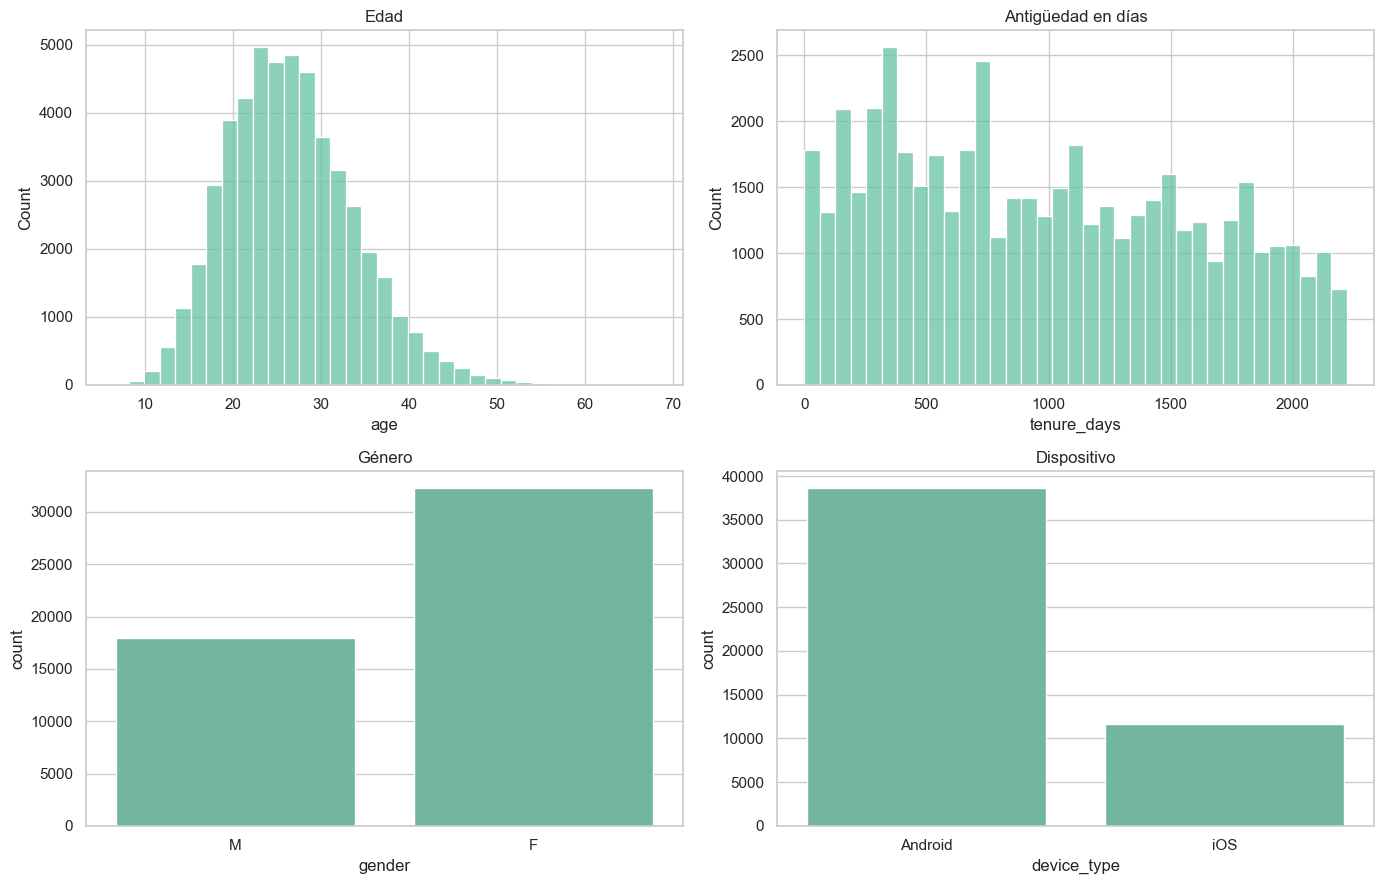

,clientes_activos
home_location,
Jakarta Raya,9294
Jawa Barat,5736
Jawa Tengah,5547
Jawa Timur,4885
Yogyakarta,3974
Kalimantan Barat,2811
Lampung,2760
Kalimantan Tengah,2169
Kalimantan Selatan,2098


,gender,device_type,clientes,monetary_mediana,frequency_mediana,recency_mediana
0,F,Android,24760,"3,025,037.00",6.00,112.00
2,M,Android,13835,"3,014,514.00",6.00,113.00
1,F,iOS,7493,"2,944,373.00",6.00,113.00
3,M,iOS,4154,"3,002,546.00",6.00,111.00


In [ ]:
if 'user_model' not in globals():
    customers_model = globals().get('customers_clean', customers).copy()
    customers_model['first_join_date'] = pd.to_datetime(customers_model['first_join_date'], errors='coerce')
    customers_model['birthdate'] = pd.to_datetime(customers_model['birthdate'], errors='coerce')
    max_join_date = customers_model['first_join_date'].max()
    customers_model['age'] = ((max_join_date - customers_model['birthdate']).dt.days / 365.25).round(1)
    customers_model['tenure_days'] = (max_join_date - customers_model['first_join_date']).dt.days
    customer_features = customers_model[[
        'customer_id', 'gender', 'device_type', 'home_location', 'home_country',
        'home_location_lat', 'home_location_long', 'age', 'tenure_days'
    ]].copy()
    user_model = rfm_model.merge(customer_features, on='customer_id', how='left')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(user_model['age'], bins=35, ax=axes[0, 0])
axes[0, 0].set_title('Edad')
sns.histplot(user_model['tenure_days'], bins=35, ax=axes[0, 1])
axes[0, 1].set_title('Antigüedad en días')
sns.countplot(data=user_model, x='gender', ax=axes[1, 0])
axes[1, 0].set_title('Género')
sns.countplot(data=user_model, x='device_type', ax=axes[1, 1])
axes[1, 1].set_title('Dispositivo')
plt.tight_layout()
plt.show()

location_counts = user_model['home_location'].value_counts().head(12)
display(location_counts.to_frame('clientes_activos'))

eda_extra = user_model.groupby(['gender', 'device_type']).agg(
    clientes=('customer_id', 'count'),
    monetary_mediana=('monetary', 'median'),
    frequency_mediana=('frequency', 'median'),
    recency_mediana=('recency', 'median'),
).reset_index().sort_values('clientes', ascending=False)
display(eda_extra)

#### PREGUNTA 6:
* Justifica qué nuevas variables consideras relevante para la segmentación y, en base a ellas, aplica las técnicas adecuadas de clustering para poder segmentar los datos.

#### RESPUESTA:

Para enriquecer la segmentación incluyo:

- RFM transformado (`log_recency`, `log_frequency`, `log_monetary`), porque sigue siendo la base comportamental más potente.
- `age`, para detectar diferencias de ciclo de vida y posible afinidad de campañas.
- `log_tenure_days`, porque la antigüedad puede separar clientes nuevos de clientes maduros.
- `gender`, `device_type` y una versión simplificada de `home_location`, como variables categóricas relevantes para comunicación, canal y localización.

Uso **K-Prototypes** porque mezcla adecuadamente distancias numéricas y coincidencias categóricas. La búsqueda de K se hace en una muestra reproducible para no penalizar la ejecución; el modelo final se ajusta sobre todos los clientes activos.

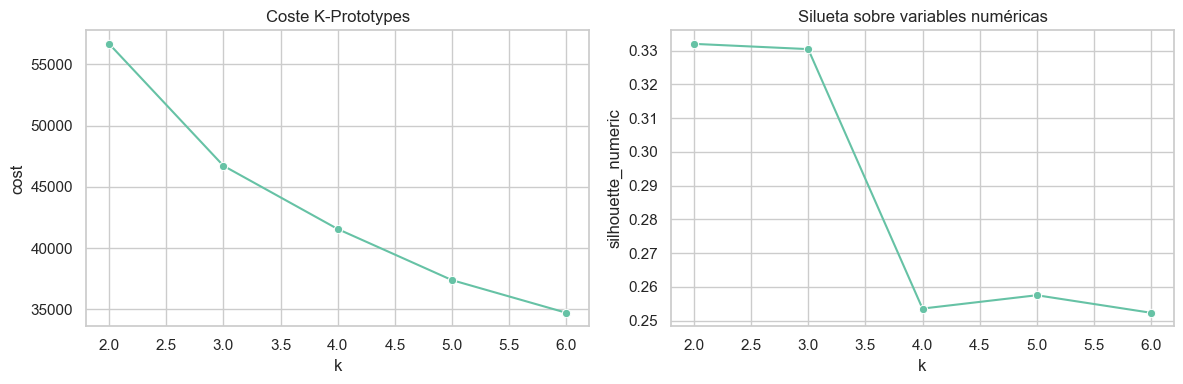

,k,cost,silhouette_numeric
0,2,"56,674.65",0.33
1,3,"46,722.63",0.33
2,4,"41,559.77",0.25
3,5,"37,387.60",0.26
4,6,"34,721.77",0.25


,clientes,recency_mediana,frequency_mediana,monetary_mediana,edad_mediana,tenure_mediana,ubicacion_principal,pct_clientes
kproto_cluster,,,,,,,,
3,12169,29.00,37.00,"20,496,212.00",25.90,"1,165.00",Other,24.22
2,15494,120.00,8.00,"4,230,392.00",26.00,"1,042.00",Other,30.84
1,6396,32.00,4.00,"1,679,968.50",26.00,133.00,Other,12.73
0,16183,584.00,1.00,"518,692.00",26.00,"1,023.00",Other,32.21


In [48]:
kproto_model = user_model.copy()

top_locations = kproto_model['home_location'].value_counts().head(8).index
kproto_model['home_location_simplified'] = np.where(
    kproto_model['home_location'].isin(top_locations),
    kproto_model['home_location'],
    'Other',
)

kproto_model['age'] = kproto_model['age'].fillna(kproto_model['age'].median()).clip(12, 90)
kproto_model['tenure_days'] = kproto_model['tenure_days'].fillna(kproto_model['tenure_days'].median()).clip(lower=0)
kproto_model['log_tenure_days'] = np.log1p(kproto_model['tenure_days'])

num_cols_kproto = ['log_recency', 'log_frequency', 'log_monetary', 'age', 'log_tenure_days']
cat_cols_kproto = ['gender', 'device_type', 'home_location_simplified']
for col in cat_cols_kproto:
    kproto_model[col] = kproto_model[col].fillna('Unknown').astype(str)

num_scaler = StandardScaler()
num_scaled = num_scaler.fit_transform(kproto_model[num_cols_kproto])
kproto_input = pd.DataFrame(num_scaled, columns=num_cols_kproto, index=kproto_model.index)
for col in cat_cols_kproto:
    kproto_input[col] = kproto_model[col].values

kproto_array = kproto_input.to_numpy(dtype=object)
cat_idx = list(range(len(num_cols_kproto), len(num_cols_kproto) + len(cat_cols_kproto)))

kproto_scores, _, sample_idx = find_optimal_k_kprototypes(kproto_array, cat_idx, min_k=2, max_k=6)
display(kproto_scores)

KPROTO_K = 4
kproto = KPrototypes(n_clusters=KPROTO_K, init='Cao', n_init=2, max_iter=20, random_state=RANDOM_STATE, verbose=0)
kproto_model['kproto_cluster'] = kproto.fit_predict(kproto_array, categorical=cat_idx)

kproto_profile = kproto_model.groupby('kproto_cluster').agg(
    clientes=('customer_id', 'count'),
    recency_mediana=('recency', 'median'),
    frequency_mediana=('frequency', 'median'),
    monetary_mediana=('monetary', 'median'),
    edad_mediana=('age', 'median'),
    tenure_mediana=('tenure_days', 'median'),
    ubicacion_principal=('home_location_simplified', lambda s: s.value_counts().idxmax()),
)
kproto_profile['pct_clientes'] = 100 * kproto_profile['clientes'] / len(kproto_model)
display(kproto_profile.sort_values('monetary_mediana', ascending=False))

#### PREGUNTA 7:
* ¿Qué insights adicionales se derivan del uso de estas variables extra? ¿Qué acciones concretas recomendarías sobre los clientes?

#### RESPUESTA:

Las variables adicionales permiten separar matices que RFM por sí solo no captura. En especial, `tenure_days` ayuda a distinguir clientes recientes con pocas compras de clientes antiguos que han dejado de comprar, aunque puedan tener valores monetarios parecidos. `device_type` y `home_location` no cambian radicalmente el valor de cliente, pero son útiles para activar campañas por canal y territorio.

Acciones recomendadas:

- **Clientes de alto valor y alta recurrencia**: fidelización, acceso anticipado y campañas de retención con baja presión promocional.
- **Clientes recientes con poca antigüedad**: onboarding, segunda compra incentivada y recomendaciones basadas en primera categoría comprada.
- **Clientes antiguos con baja recencia**: win-back con incentivo controlado y ventanas de caducidad cortas.
- **Segmentos por dispositivo/ubicación**: adaptar creatividades y logística; por ejemplo, campañas mobile-first en Android si concentra la mayoría de usuarios y promociones geolocalizadas en provincias densas.

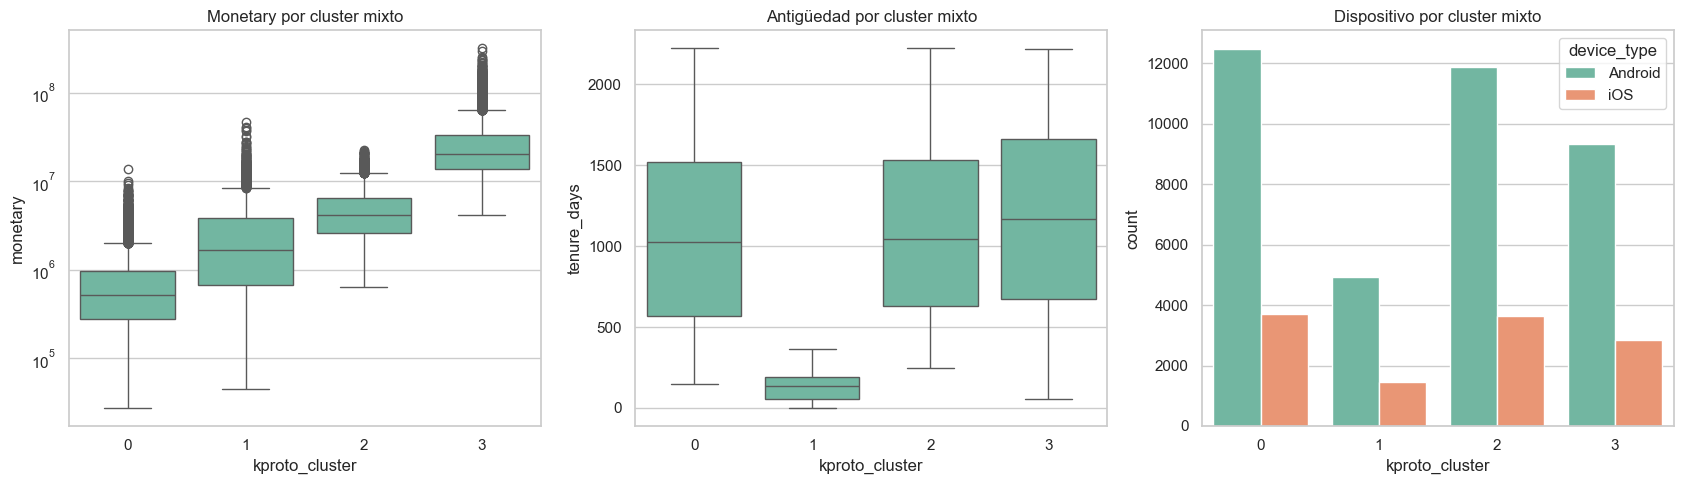

gender,F,M
kproto_cluster,,
0,0.64,0.36
1,0.64,0.36
2,0.65,0.35
3,0.64,0.36


device_type,Android,iOS
kproto_cluster,,
0,0.77,0.23
1,0.77,0.23
2,0.77,0.23
3,0.77,0.23


home_location_simplified,Jakarta Raya,Jawa Barat,Jawa Tengah,Jawa Timur,Kalimantan Barat,Kalimantan Tengah,Lampung,Other,Yogyakarta
kproto_cluster,,,,,,,,,
0,0.18,0.11,0.11,0.10,0.06,0.04,0.06,0.26,0.08
1,0.19,0.12,0.11,0.09,0.06,0.04,0.06,0.26,0.08
2,0.19,0.11,0.11,0.10,0.06,0.04,0.06,0.26,0.08
3,0.18,0.12,0.11,0.10,0.05,0.04,0.05,0.26,0.08


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.boxplot(data=kproto_model, x='kproto_cluster', y='monetary', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Monetary por cluster mixto')
sns.boxplot(data=kproto_model, x='kproto_cluster', y='tenure_days', ax=axes[1])
axes[1].set_title('Antigüedad por cluster mixto')
sns.countplot(data=kproto_model, x='kproto_cluster', hue='device_type', ax=axes[2])
axes[2].set_title('Dispositivo por cluster mixto')
plt.tight_layout()
plt.show()

display(pd.crosstab(kproto_model['kproto_cluster'], kproto_model['gender'], normalize='index').round(3))
display(pd.crosstab(kproto_model['kproto_cluster'], kproto_model['device_type'], normalize='index').round(3))
display(pd.crosstab(kproto_model['kproto_cluster'], kproto_model['home_location_simplified'], normalize='index').round(3))

## 5. Clustering Geográfico con DBSCAN

#### PREGUNTA 8:
* Analiza los datos de geolocalización de los lugares de residencia y realiza una segmentación de clientes en base a dicha información utilizando DBSCAN

#### RESPUESTA:

Para DBSCAN uso las coordenadas de residencia (`home_location_lat`, `home_location_long`) y la distancia haversine, apropiada para latitud/longitud. Se prueban varios valores de `eps` en kilómetros y se mantiene `min_samples=100` para buscar concentraciones geográficas relevantes a escala comercial, no microgrupos anecdóticos.

Clientes con geolocalización válida: 100,000


,count,mean,std,min,25%,50%,75%,max
home_location_lat,"100,000.00",-5.11,3.09,-10.85,-7.37,-6.24,-3.09,5.82
home_location_long,"100,000.00",110.94,6.34,95.28,106.86,110.16,113.17,140.99


,clientes
home_location,
Jakarta Raya,18715
Jawa Barat,11486
Jawa Tengah,10960
Jawa Timur,9953
Yogyakarta,7849
Kalimantan Barat,5603
Lampung,5426
Kalimantan Selatan,4229
Kalimantan Tengah,4091


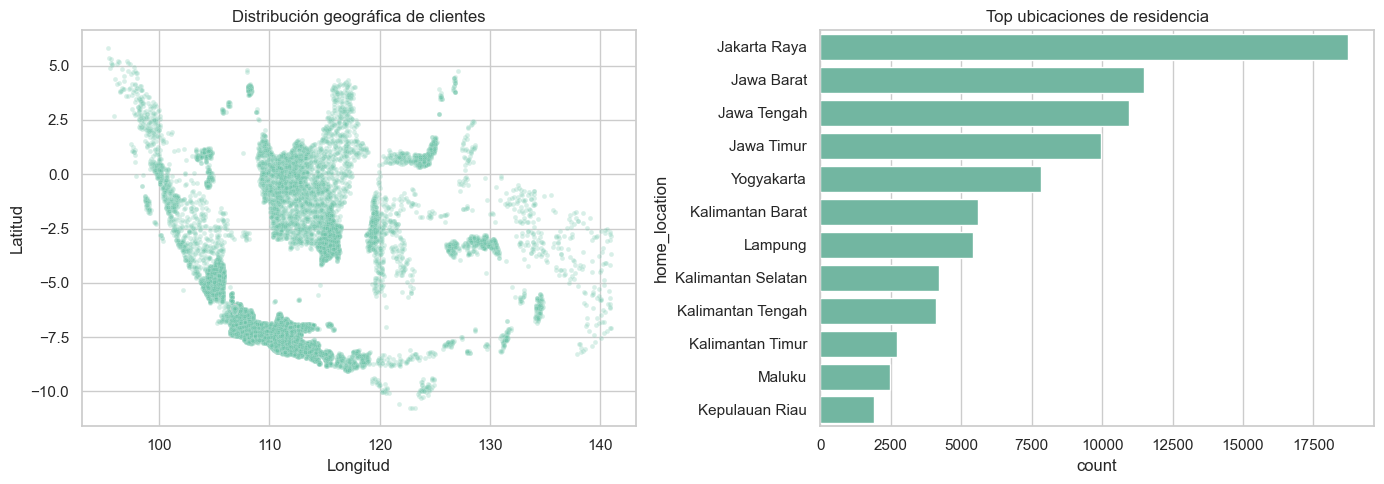

,eps_km,min_samples,n_clusters,noise_pct,largest_cluster
0,20,100,12,26.96,60126
1,35,100,18,9.89,66322
2,50,100,15,5.00,70661


,clientes,lat_centro,lon_centro,ubicacion_principal,pct_clientes_geo
geo_cluster,,,,,
0,70661,-6.63,108.66,Jakarta Raya,70.66
1,16544,-0.99,113.62,Kalimantan Barat,16.54
5,1809,-2.85,119.63,Sulawesi Barat,1.81
4,1519,0.84,123.72,Sulawesi Utara,1.52
2,1263,0.50,104.28,Kepulauan Riau,1.26
7,995,-3.21,129.35,Maluku,0.99
9,464,-3.43,126.64,Maluku,0.46
6,424,-6.19,134.46,Maluku,0.42
8,399,3.92,108.19,Kepulauan Riau,0.40


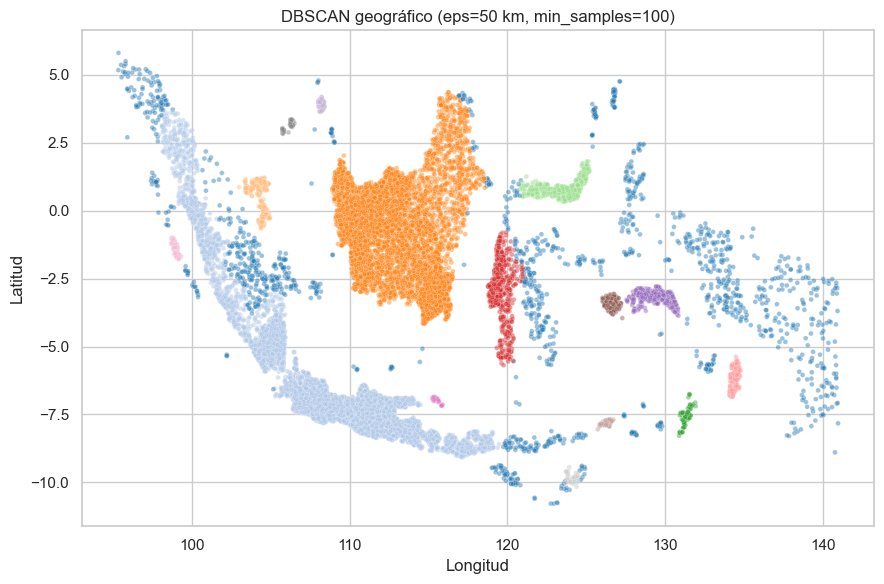

In [50]:
geo_model = customers_model[['customer_id', 'home_location_lat', 'home_location_long', 'home_location']].dropna().copy()
print(f'Clientes con geolocalización válida: {len(geo_model):,}')

display(geo_model[['home_location_lat', 'home_location_long']].describe().T)
display(geo_model['home_location'].value_counts().head(12).to_frame('clientes'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=geo_model.sample(min(20_000, len(geo_model)), random_state=RANDOM_STATE),
    x='home_location_long', y='home_location_lat', alpha=.25, s=12, ax=axes[0]
)
axes[0].set_title('Distribución geográfica de clientes')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
sns.countplot(data=geo_model, y='home_location', order=geo_model['home_location'].value_counts().head(12).index, ax=axes[1])
axes[1].set_title('Top ubicaciones de residencia')
plt.tight_layout()
plt.show()

coords_rad = np.radians(geo_model[['home_location_lat', 'home_location_long']].to_numpy())
earth_radius_km = 6371.0088

dbscan_rows = []
for eps_km in [20, 35, 50]:
    db = DBSCAN(
        eps=eps_km / earth_radius_km,
        min_samples=100,
        metric='haversine',
        algorithm='ball_tree',
    )
    labels = db.fit_predict(coords_rad)
    dbscan_rows.append({
        'eps_km': eps_km,
        'min_samples': 100,
        'n_clusters': len(set(labels) - {-1}),
        'noise_pct': 100 * np.mean(labels == -1),
        'largest_cluster': pd.Series(labels).value_counts().drop(labels=-1, errors='ignore').max(),
    })

dbscan_scores = pd.DataFrame(dbscan_rows)
display(dbscan_scores)

# eps=50 km reduce bastante el ruido sin fusionar todo el país en un único cluster.
DBSCAN_EPS_KM = 50
geo_dbscan = DBSCAN(
    eps=DBSCAN_EPS_KM / earth_radius_km,
    min_samples=100,
    metric='haversine',
    algorithm='ball_tree',
)
geo_model['geo_cluster'] = geo_dbscan.fit_predict(coords_rad)

geo_profile = (
    geo_model[geo_model['geo_cluster'] != -1]
    .groupby('geo_cluster')
    .agg(
        clientes=('customer_id', 'count'),
        lat_centro=('home_location_lat', 'mean'),
        lon_centro=('home_location_long', 'mean'),
        ubicacion_principal=('home_location', lambda s: s.value_counts().idxmax()),
    )
    .sort_values('clientes', ascending=False)
)
geo_profile['pct_clientes_geo'] = 100 * geo_profile['clientes'] / len(geo_model)
display(geo_profile.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
plot_geo = geo_model.sample(min(30_000, len(geo_model)), random_state=RANDOM_STATE)
sns.scatterplot(data=plot_geo, x='home_location_long', y='home_location_lat', hue='geo_cluster', palette='tab20', s=12, alpha=.45, ax=ax, legend=False)
ax.set_title(f'DBSCAN geográfico (eps={DBSCAN_EPS_KM} km, min_samples=100)')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()

#### PREGUNTA 9:
* ¿Qué insights se derivan de esta segmentación y qué acciones concretas propondrías?

#### RESPUESTA:

DBSCAN identifica concentraciones naturales de clientes en zonas densas y deja como ruido ubicaciones dispersas. Esto es útil porque no obliga a prefijar el número de regiones y permite detectar áreas donde una acción logística o comercial puede tener masa crítica.

Insights y acciones concretas:

- Las mayores concentraciones geográficas deben priorizar campañas locales, acuerdos logísticos y promociones con ventanas de entrega realistas.
- Los clusters pequeños pero densos pueden usarse para pruebas A/B regionales con menor coste.
- Los puntos etiquetados como ruido no deben descartarse como clientes; simplemente no forman una concentración suficiente para acciones geográficas masivas. Para ellos convienen campañas digitales no geolocalizadas o segmentación por RFM.
- Cruzar cluster geográfico con RFM permite distinguir regiones con mucha base de clientes de regiones con alto valor medio, que no siempre coinciden.

,clientes,compradores_activos_pct,monetary_mediana,frequency_mediana,recency_mediana,ubicacion_principal
geo_cluster,,,,,,
0,70661,50.06,"3,025,556.00",6.00,111.00,Jakarta Raya
1,16544,50.80,"3,025,036.00",6.00,117.00,Kalimantan Barat
-1,5003,50.73,"2,825,746.00",5.00,119.00,Papua
5,1809,48.65,"2,644,747.50",5.00,119.00,Sulawesi Barat
4,1519,50.16,"3,077,526.00",6.00,107.50,Sulawesi Utara
2,1263,51.70,"3,076,487.00",5.00,109.00,Kepulauan Riau
7,995,50.65,"3,090,466.00",6.00,120.50,Maluku
9,464,50.65,"3,180,987.00",5.00,115.00,Maluku
6,424,54.01,"3,203,826.00",6.00,128.00,Maluku


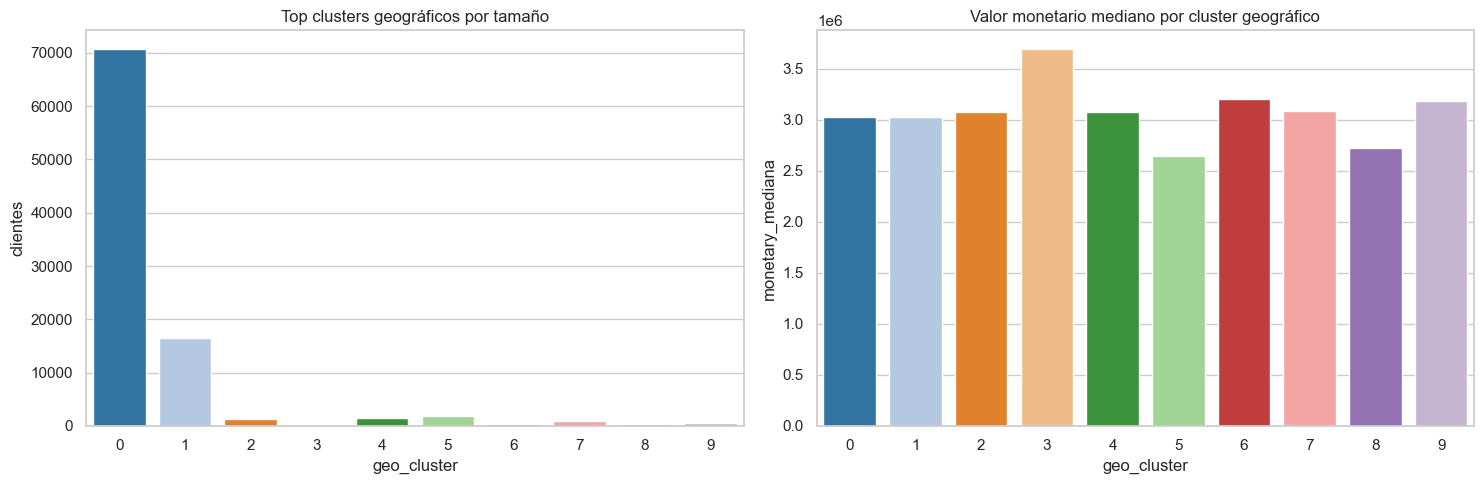

In [51]:
geo_business = geo_model.merge(rfm_model[['customer_id', 'recency', 'frequency', 'monetary', 'kmeans_segment']], on='customer_id', how='left')
geo_business['is_active_buyer'] = geo_business['monetary'].notna()

geo_business_profile = (
    geo_business
    .groupby('geo_cluster')
    .agg(
        clientes=('customer_id', 'count'),
        compradores_activos_pct=('is_active_buyer', lambda s: 100 * s.mean()),
        monetary_mediana=('monetary', 'median'),
        frequency_mediana=('frequency', 'median'),
        recency_mediana=('recency', 'median'),
        ubicacion_principal=('home_location', lambda s: s.value_counts().idxmax()),
    )
    .sort_values('clientes', ascending=False)
)
display(geo_business_profile.head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_geo_clusters = geo_business_profile[geo_business_profile.index != -1].head(10).index
sns.barplot(
    data=geo_business_profile.loc[top_geo_clusters].reset_index(),
    x='geo_cluster', y='clientes', ax=axes[0], palette='tab20'
)
axes[0].set_title('Top clusters geográficos por tamaño')
sns.barplot(
    data=geo_business_profile.loc[top_geo_clusters].reset_index(),
    x='geo_cluster', y='monetary_mediana', ax=axes[1], palette='tab20'
)
axes[1].set_title('Valor monetario mediano por cluster geográfico')
plt.tight_layout()
plt.show()


## Declaración de uso de IA generativa

Para la elaboración de esta entrega se ha utilizado un asistente de IA generativa como apoyo en la estructuración del análisis, revisión de código, redacción de explicaciones y comprobación de coherencia con la rúbrica. El notebook mantiene trazabilidad mediante código ejecutable, visualizaciones y tablas de resultados para que las conclusiones puedan ser verificadas y evaluadas de forma transparente.
